In [1]:
from plntxps import *

from darkplot import *

# 1/24/25 SA 450

In [2]:
SA_450_1_24 = datafile('example data/Experiment 2025-1-24 SA 450.xy')

SA_450_Au_1_24 = datafile('example data/Experiment 2025-1-24 Au SA 450.xy')

In [3]:
SA_450_1_24.list_spectra()

Index  Name          Time (min)  Comment             
0      Ti 2p         529.27      
       Peak Location
.....................................................
1      O 1s          531.13      
       Peak Location
.....................................................
2      Ti 2p         532.65      
       Peak Location
.....................................................
3      O 1s          534.52      
       Peak Location
.....................................................
4      Ti 2p         536.02      
       Peak Location
.....................................................
5      O 1s          537.88      
       Peak Location
.....................................................
6      Ti 2p         539.40      
       Peak Location
.....................................................
7      O 1s          541.25      
       Peak Location
.....................................................
8      Ti 2p         542.77      
       Peak Location
...................

In [4]:
SA_450_1_24.spectrum_table

,Name,Time (minute),Comment,Max,Min,Pass Energy,Lens Mode,Slits
0,Ti 2p,529.266667,,469.95000,450.05000,10.0,LargeArea:1.5kV,8:7dia.\B:open
1,O 1s,531.133333,,539.95000,515.05000,10.0,LargeArea:1.5kV,8:7dia.\B:open
2,Ti 2p,532.650000,,469.95000,450.05000,10.0,LargeArea:1.5kV,8:7dia.\B:open
3,O 1s,534.516667,,539.95000,515.05000,10.0,LargeArea:1.5kV,8:7dia.\B:open
4,Ti 2p,536.016667,,469.95000,450.05000,10.0,LargeArea:1.5kV,8:7dia.\B:open
...,...,...,...,...,...,...,...,...
227,Valence Band,802.350000,,14.95000,-0.95000,10.0,LargeArea:1.5kV,8:7dia.\B:open
228,Ti 2p,804.116667,,461.17632,457.62368,10.0,LargeArea:1.5kV,8:7dia.\B:open
229,O 1s,805.900000,,532.97500,529.02500,10.0,LargeArea:1.5kV,8:7dia.\B:open
230,Ti 2p,807.650000,,461.17632,457.62368,10.0,LargeArea:1.5kV,8:7dia.\B:open


O 1s peak position: 530.1178 +- 0.0141
Ti 2p peak position: 458.9028 +- 0.0209


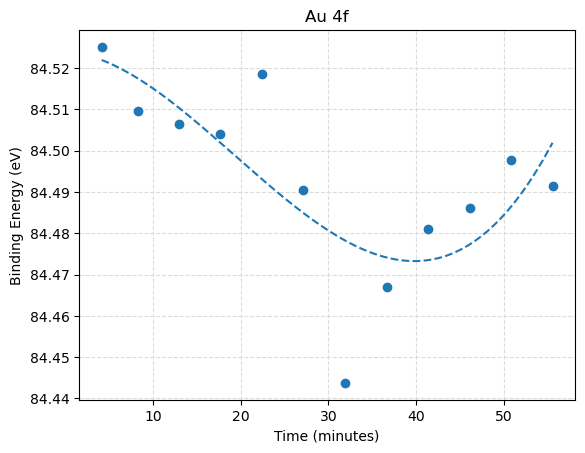

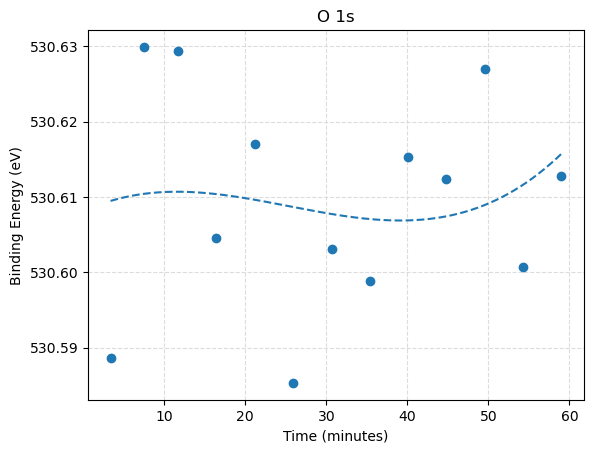

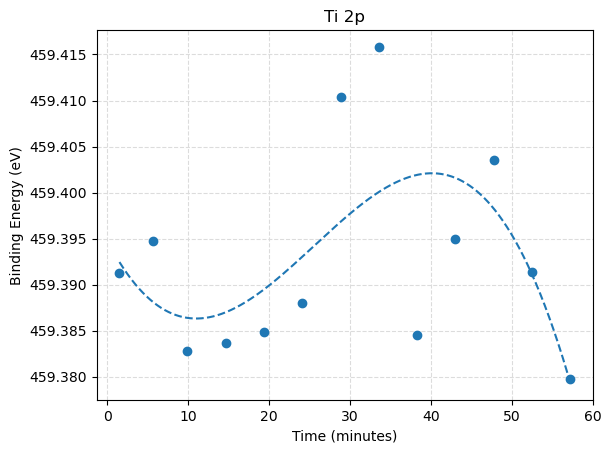

In [5]:
SA_450_Au_1_24.get_charge_referenced_peak_positions([1, 60], plot_result=True)

time slice excludes 8 of 150 valence band spectra


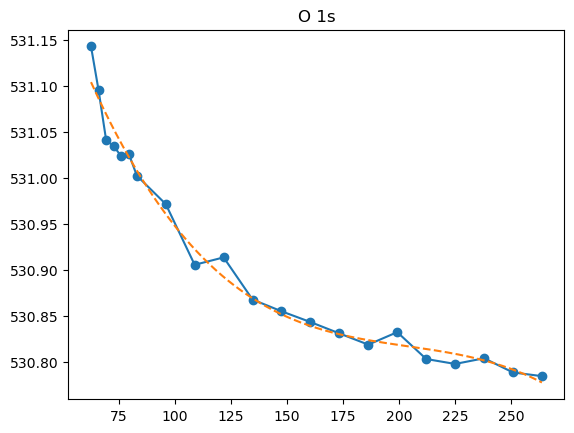

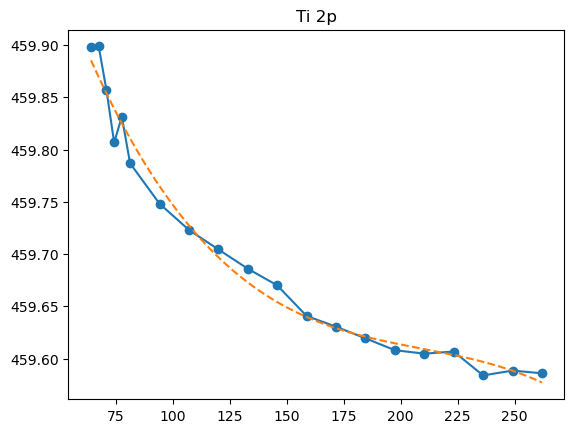

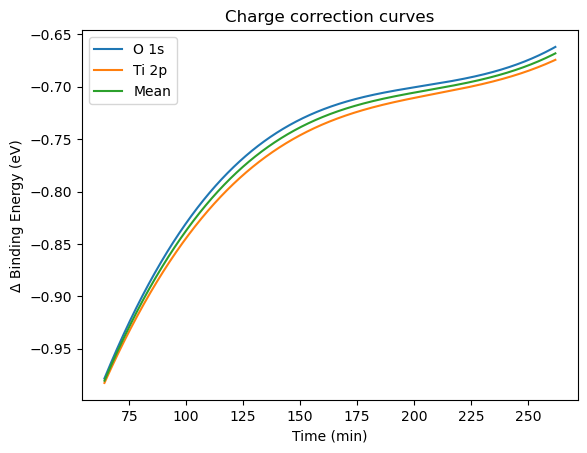

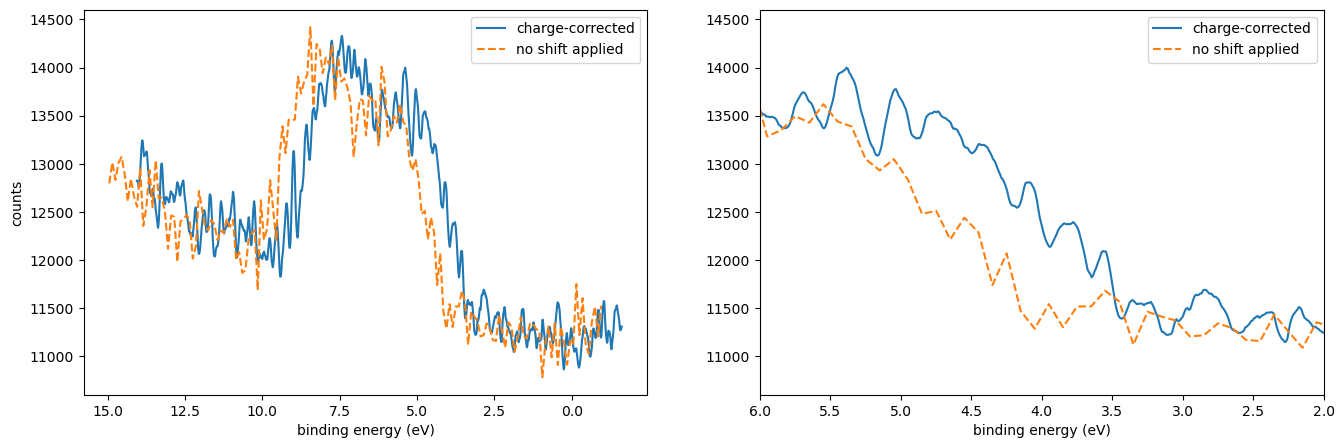

In [6]:
SA_450_1_24.charge_reference_valence_band_spectra([62, 266], SA_450_Au_1_24)

Valence Band Maximum: 2.873771524263772 eV


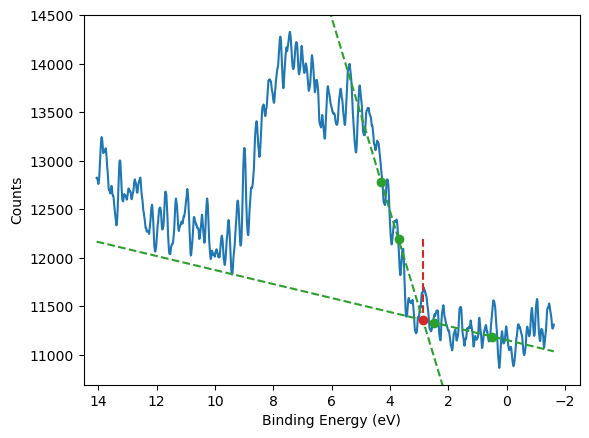

In [7]:
SA_450_1_24.find_fermi_edge_linfit([0.5, 2.5], [3.7, 4.3], instrumental_broadening = 0)
plt.xlim(14.5, -2.5)
plt.savefig('fermi_edge_linfit.svg')
plt.savefig('fermi_edge_linfit.png')

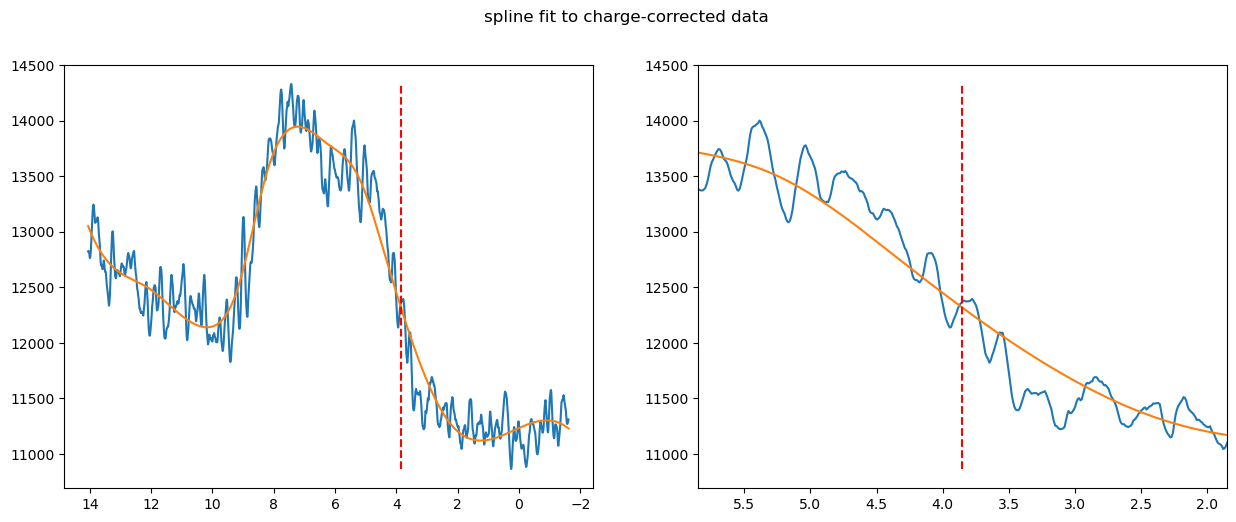

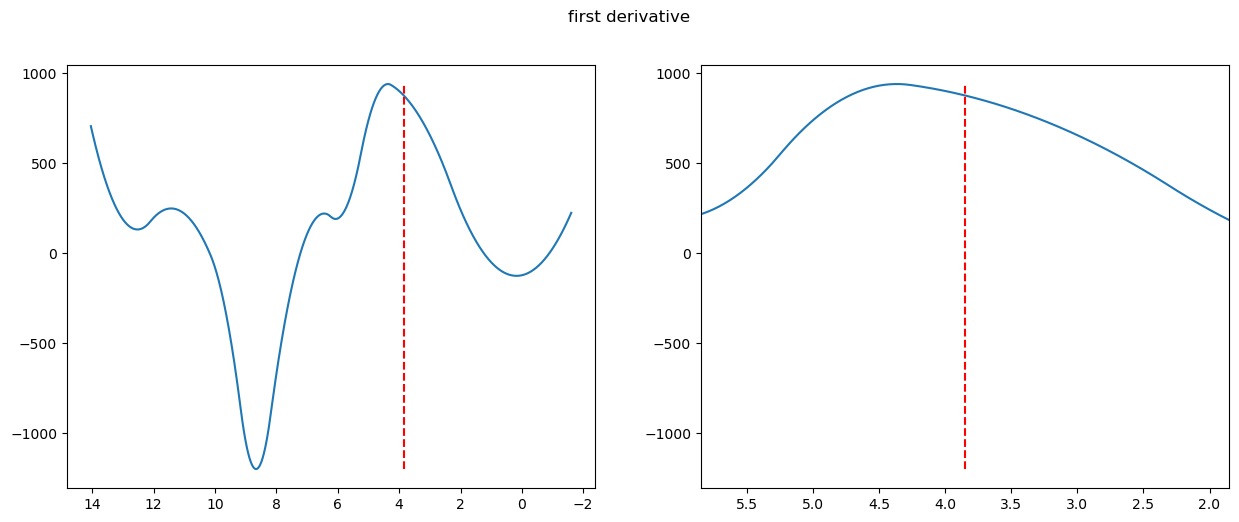

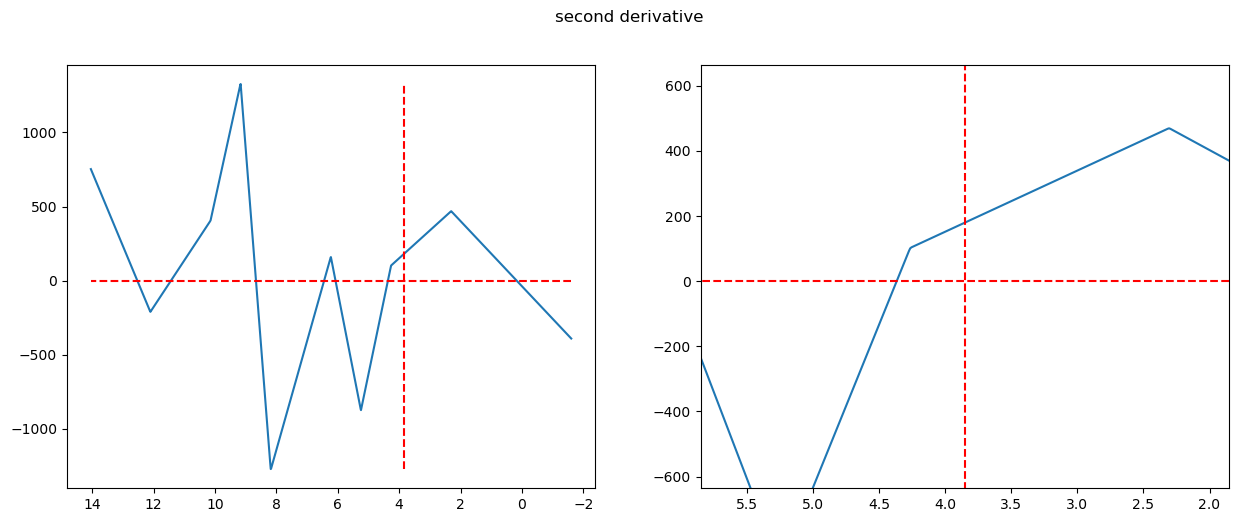

In [8]:
SA_450_1_24.find_fermi_edge(7E7, 3.85)
plt.savefig('fermi_edge_seconddir.svg')
plt.savefig('fermi_edge_seconddir.png')

# 9-16-24 RhAl2O3 for Marlon

In [9]:
RhAl2O3 = datafile("example data/2024-09-16 Rh on Al2O3 for Marlon 7-21-24 fit.xy")

# 6-15-26 UPS of LaB6

In [10]:
LaB6 = read_datafile("example data/6-12-26 UPS on LaB6.xy")

In [11]:
LaB6.list_spectra()

Index  Name                 Time (min)  Comment             
0      Spectrum             1093.20     No light on
............................................................
1      Spectrum             1094.80     
............................................................
2      Spectrum             1099.47     
............................................................
3      Spectrum             1101.25     
............................................................
4      UPS                  1097.95     
............................................................
5      UPS                  1103.58     
............................................................
6      UPS                  1117.53     Light on (410)
............................................................
7      UPS                  1119.05     
............................................................
8      UPS                  1122.82     moved light to the right a bit
...........................

In [12]:
for index, spectrum in enumerate(LaB6.spectra):
    print(f"{index}: {len(spectrum.scans)/5}")

0: 1.0
1: 1.0
2: 1.0
3: 1.0
4: 1.0
5: 1.0
6: 1.0
7: 1.0
8: 1.0
9: 1.0
10: 1.0
11: 1.0
12: 1.0
13: 1.0
14: 1.0
15: 1.0
16: 1.0
17: 11.0
18: 4.0
19: 5.0


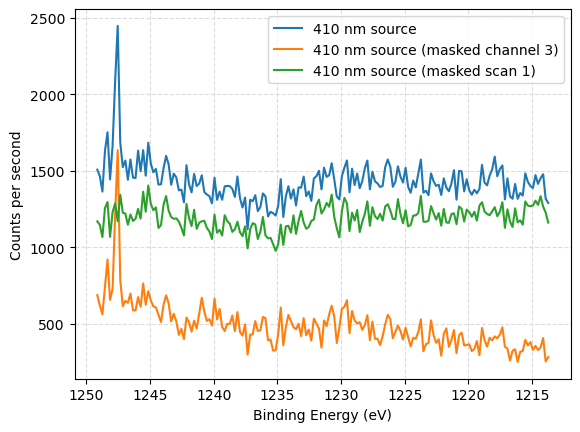

In [13]:
plt.plot(LaB6.spectra[17].eV, LaB6.spectra[17].counts, label = '410 nm source')
plt.plot(LaB6.spectra[17].eV, LaB6.spectra[17].masked_counts(channel_mask=[3]),
        label = '410 nm source (masked channel 3)')
plt.plot(LaB6.spectra[17].eV, LaB6.spectra[17].masked_counts(scan_mask=[1]),
        label = '410 nm source (masked scan 1)')
plt.legend()
plt.gca().invert_xaxis()
plt.xlabel('Binding Energy (eV)')
plt.ylabel("Counts per second")
plt.grid(color = 'gainsboro', ls = 'dashed')

# verify the model DS peak asymmetry goes the right way

In [29]:
peak_table = pd.DataFrame()
peak_table["peak name"] = ["example"]
peak_table["processed peak name"] = ["example"]
peak_table["has satellites"] = ["False"]
peak_table["peak shape"] = ["DS"]
peak_table

,peak name,processed peak name,has satellites,peak shape
0,example,example,False,DS


In [30]:
model = setup_fit_model(peak_table, 'none', [])

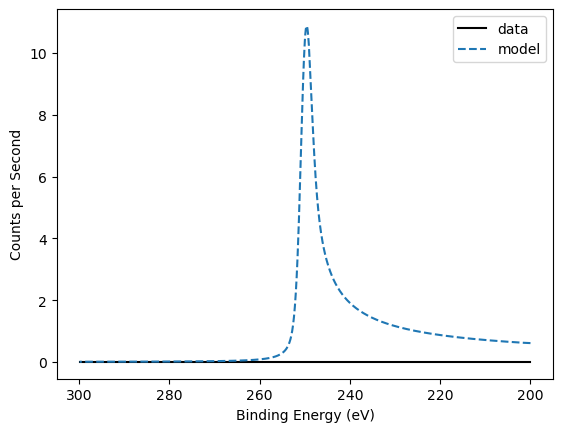

In [40]:
eV = np.arange(200, 300, 0.1)
counts = np.array([0] * len(eV))
plot_initial_guess(model, "example data/asymmetry check params.csv", eV, counts, False);

# satellite peak fitting

In [15]:
satellites = read_satellite_peaks('example data/perkin elmer mg satellites.csv')

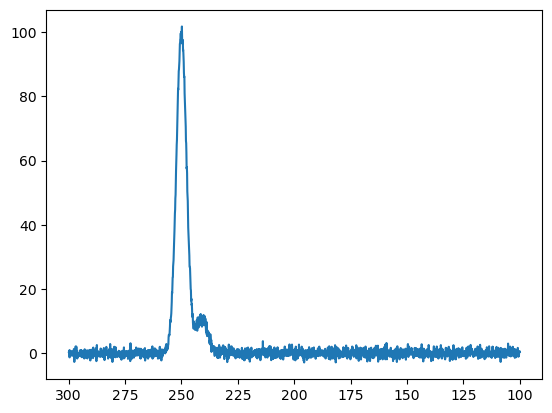

In [16]:
# generate fake data

def source_peak(eV, shift, intensity):
    return np.exp(-((eV-250 + shift)**2)/10)*intensity

rng = np.random.default_rng(seed = 1)

eV = np.arange(100, 300, 0.1)[::-1]
counts = np.zeros(len(eV)) + rng.normal(0, 1, size = eV.shape)
for satellite in satellites.values():
    counts += source_peak(eV, satellite['position'], satellite['intensity'])
plt.plot(eV, counts)
plt.gca().invert_xaxis()

In [17]:
peak_table = pd.DataFrame()
peak_table["peak name"] = ["example"]
peak_table["processed peak name"] = ["example"]
peak_table["has satellites"] = ["True"]
peak_table["peak shape"] = ["DS"]
peak_table

,peak name,processed peak name,has satellites,peak shape
0,example,example,True,DS


In [18]:
result = fit_procedure(eV, counts, peak_table, "example data/fit params.csv",
          bg_type = 'none', satellites = satellites)

/home/work/.local/lib/python3.14/site-packages/lmfit/model.py:1127: UserWarning: The keyword argument y does not match any arguments of the model function. It will be ignored.
  warnings.warn(f"The keyword argument {name} does not " +


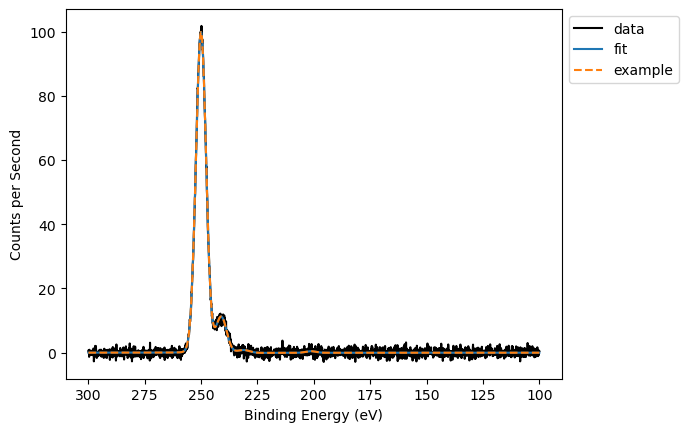

In [19]:
plot_fit_result(eV, counts, result, satellites, peak_table)

# spectrum from eV and counts

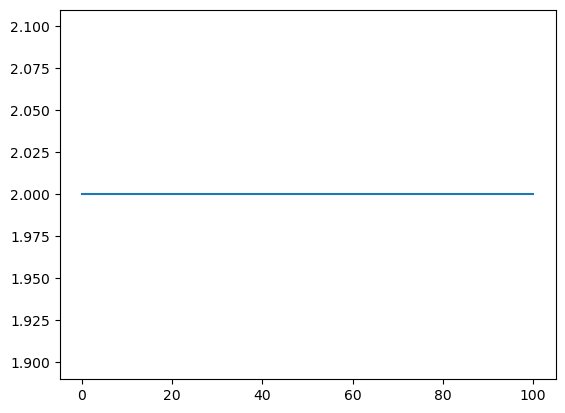

In [20]:
test_eV = np.arange(100, 0, -0.1)
test_counts = np.zeros(len(test_eV)) + 2
test_spectrum = new_spectrum(test_eV, test_counts, photon_energy = PHOTON_ENERGY['Mg'])
test_spectrum.plot()

In [21]:
test_spectrum.kinetic_energy

array([1149.057, 1149.157, 1149.257, 1149.357, 1149.457, 1149.557,
       1149.657, 1149.757, 1149.857, 1149.957, 1150.057, 1150.157,
       1150.257, 1150.357, 1150.457, 1150.557, 1150.657, 1150.757,
       1150.857, 1150.957, 1151.057, 1151.157, 1151.257, 1151.357,
       1151.457, 1151.557, 1151.657, 1151.757, 1151.857, 1151.957,
       1152.057, 1152.157, 1152.257, 1152.357, 1152.457, 1152.557,
       1152.657, 1152.757, 1152.857, 1152.957, 1153.057, 1153.157,
       1153.257, 1153.357, 1153.457, 1153.557, 1153.657, 1153.757,
       1153.857, 1153.957, 1154.057, 1154.157, 1154.257, 1154.357,
       1154.457, 1154.557, 1154.657, 1154.757, 1154.857, 1154.957,
       1155.057, 1155.157, 1155.257, 1155.357, 1155.457, 1155.557,
       1155.657, 1155.757, 1155.857, 1155.957, 1156.057, 1156.157,
       1156.257, 1156.357, 1156.457, 1156.557, 1156.657, 1156.757,
       1156.857, 1156.957, 1157.057, 1157.157, 1157.257, 1157.357,
       1157.457, 1157.557, 1157.657, 1157.757, 1157.857, 1157.

# shirley background

(300.0, 1200.0)

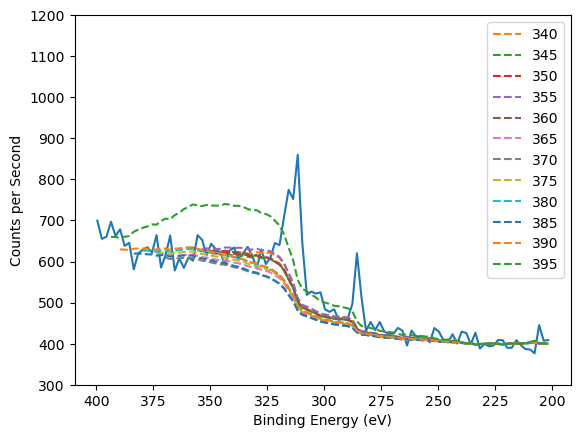

In [22]:
slice_upper_bounds = np.arange(340, 400, 5)
guinea_pig = RhAl2O3.spectra[0].slice(200, 400)
guinea_pig.plot()
for upper_bound in slice_upper_bounds:
    background_slice = guinea_pig.slice(200, upper_bound)
    background = shirley_background(background_slice.counts, 3)
    plt.plot(
        background_slice.eV, background,
        ls = 'dashed', label = upper_bound)

plt.legend()
boilerplate()
#plt.xlim(400, 200)
plt.ylim(3e2, 1.2e3)